In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv(r"C:\Calibo\House price prediction\House PricePrediction Dataset.csv")

In [3]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [4]:
df.tail()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119
1999,2000,2989,5,1,3,1903,Suburban,Fair,No,482525


In [5]:
df.shape


(2000, 10)

In [6]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 184.3 KB


In [8]:
print(df.columns.tolist())

['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']


In [9]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [10]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
for i, col in enumerate(df.columns):
    print(i, ":", col)

0 : Id
1 : Area
2 : Bedrooms
3 : Bathrooms
4 : Floors
5 : YearBuilt
6 : Location
7 : Condition
8 : Garage
9 : Price


In [13]:
df.nunique()

Id           2000
Area         1622
Bedrooms        5
Bathrooms       4
Floors          3
YearBuilt     124
Location        4
Condition       4
Garage          2
Price        1999
dtype: int64

In [14]:
df['Location'].unique()

<ArrowStringArray>
['Downtown', 'Suburban', 'Urban', 'Rural']
Length: 4, dtype: str

In [15]:
df['Condition'].unique()

<ArrowStringArray>
['Excellent', 'Good', 'Fair', 'Poor']
Length: 4, dtype: str

In [16]:
df['Garage'].unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [17]:
df['Location'].value_counts()

Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64

In [18]:
df['Condition'].value_counts()

Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64

In [19]:
df['Garage'].value_counts()

Garage
No     1038
Yes     962
Name: count, dtype: int64

In [20]:
numeric_cols = [
    'Area',
    'Bedrooms',
    'Bathrooms',
    'Floors',
    'YearBuilt'
]

print(numeric_cols)

['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']


In [21]:
y = df['Price']

print(y.name)

Price


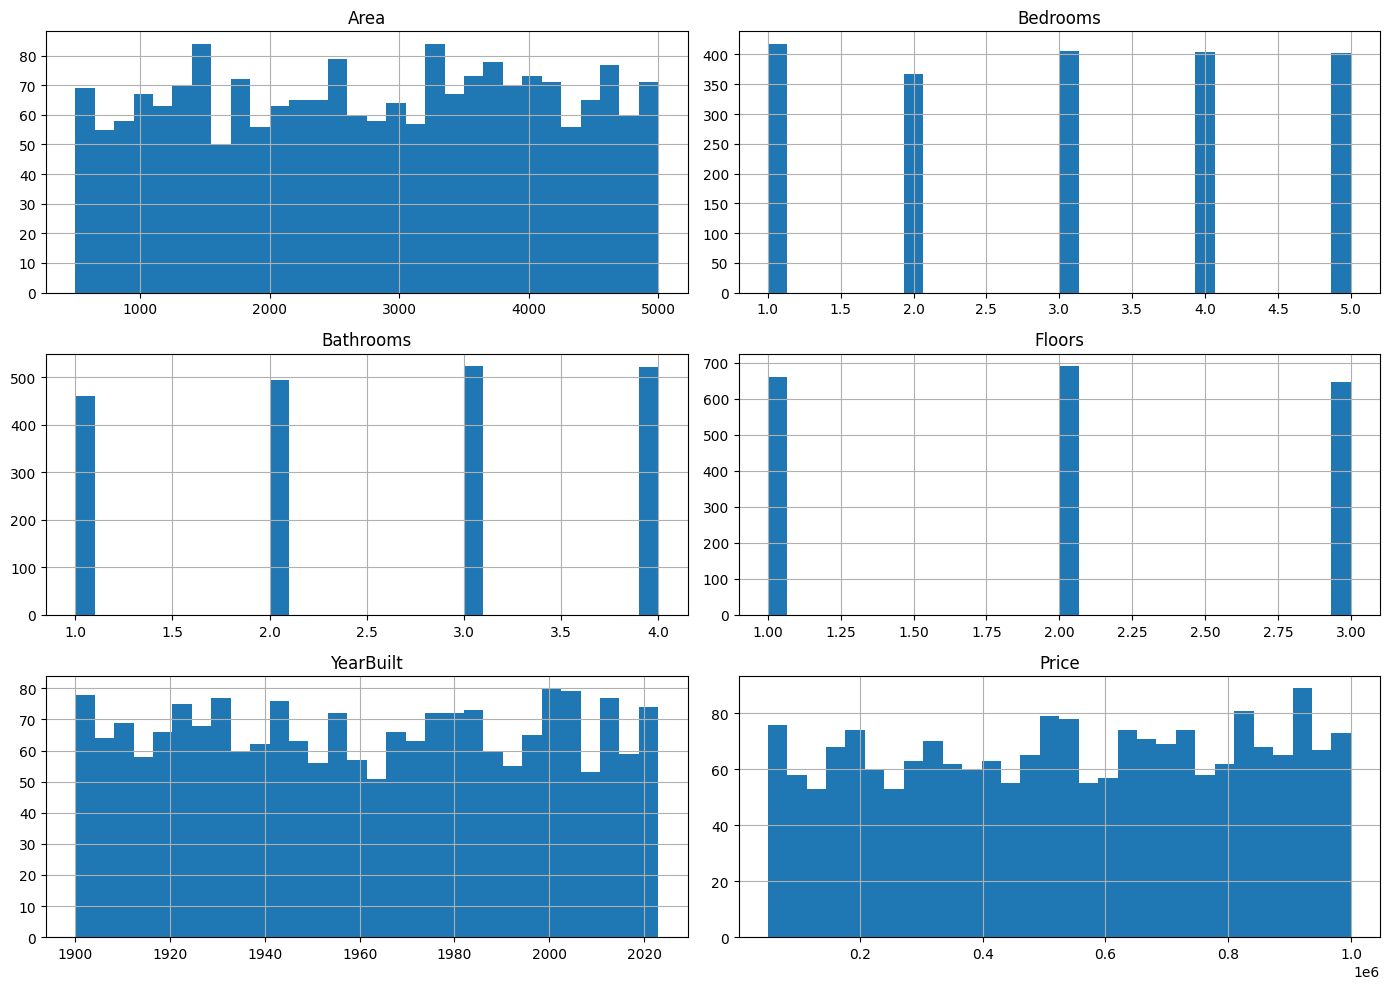

In [22]:
import matplotlib.pyplot as plt

df[numeric_cols + [y.name]].hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()

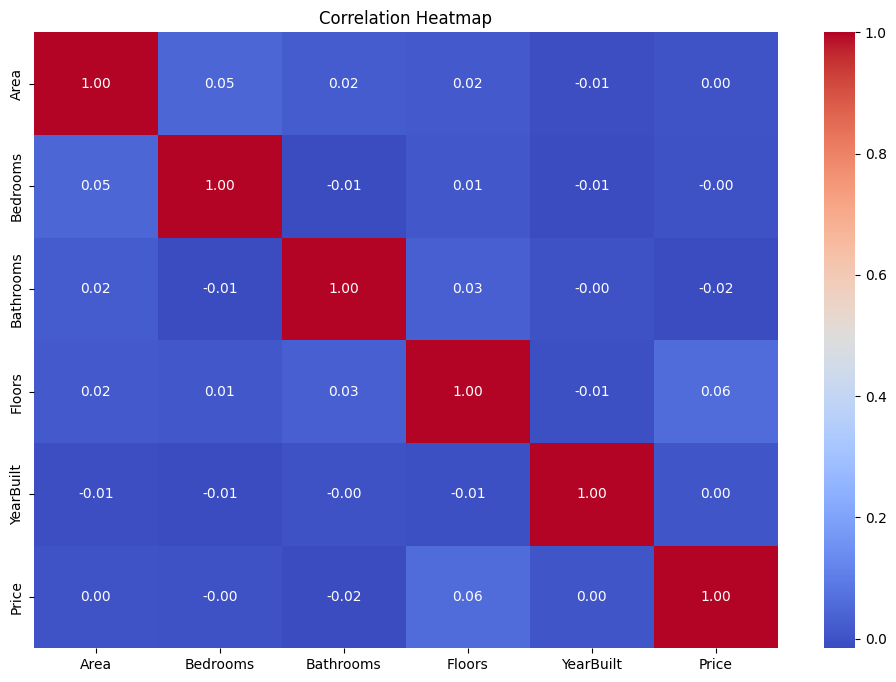

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numeric_cols + [y.name]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

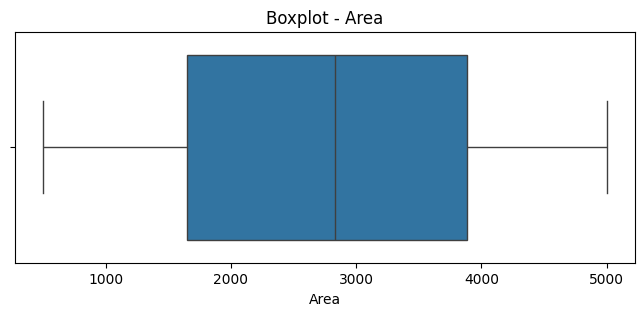

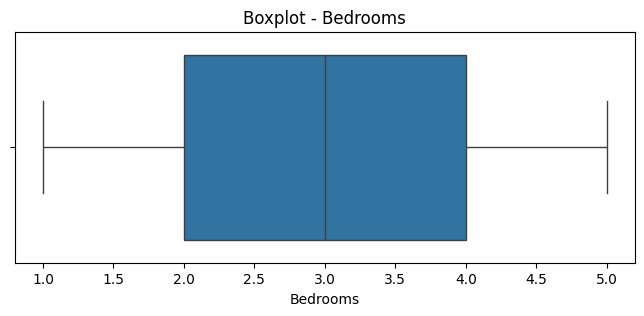

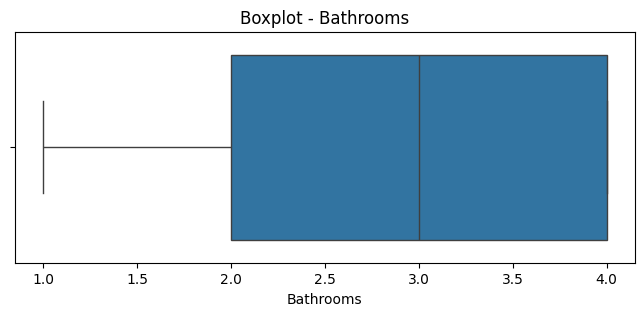

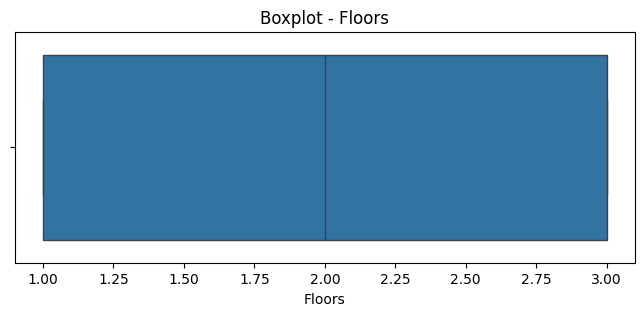

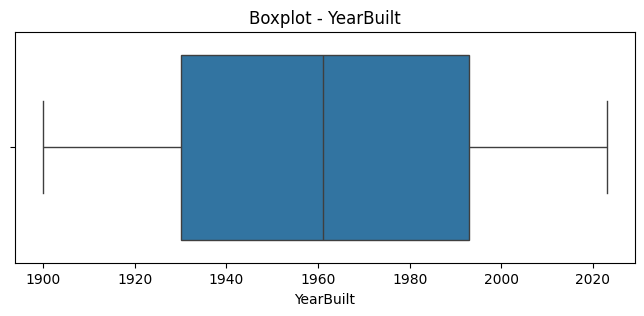

In [24]:
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

In [25]:
df.select_dtypes(include=np.number).skew()

Id           0.000000
Area        -0.038552
Bedrooms    -0.021753
Bathrooms   -0.066546
Floors       0.011837
YearBuilt   -0.001577
Price       -0.064351
dtype: float64

In [26]:
X_reg = df.drop('Price', axis=1)
y_reg = df['Price']

print("X shape:", X_reg.shape)
print("y shape:", y_reg.shape)

X shape: (2000, 9)
y shape: (2000,)


In [27]:
import numpy as np

numeric_features = X_reg.select_dtypes(include=np.number).columns.tolist()

categorical_features = X_reg.select_dtypes(  include='object').columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']

Categorical features:
['Location', 'Condition', 'Garage']


C:\Users\KEERTHI\AppData\Local\Temp\ipykernel_33008\102998242.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_reg.select_dtypes(  include='object').columns.tolist()


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])

print("Preprocessor created successfully")

Preprocessor created successfully


In [29]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split( X_reg, y_reg,test_size=0.2,random_state=42)

print("X_train:", X_train_reg.shape)
print("X_test :", X_test_reg.shape)
print("y_train:", y_train_reg.shape)
print("y_test :", y_test_reg.shape)

X_train: (1600, 9)
X_test : (400, 9)
y_train: (1600,)
y_test : (400,)


LINEAR REGRESSION

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[ ('num', StandardScaler(), numeric_features),('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) ])

print("Preprocessor created successfully")

Preprocessor created successfully


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[('preprocessor', preprocessor),('model', LinearRegression()) ])

print("Linear Regression model created successfully")

Linear Regression model created successfully


In [33]:
linear_model = Pipeline(
    steps=[ ('preprocessor', preprocessor), ('model', LinearRegression()) ])

print("Linear Regression model created successfully")

Linear Regression model created successfully


In [34]:
linear_model.fit(X_train_reg, y_train_reg)

print("Linear Regression model trained successfully")

Linear Regression model trained successfully


In [35]:
y_pred = linear_model.predict(X_test_reg)

print("Predictions created successfully")
print("Number of predictions:", len(y_pred))

Predictions created successfully
Number of predictions: 400


In [36]:
# First 10 predicted values

print("First 10 Actual Prices:")
print(y_test_reg.iloc[:10].values)

print("\nFirst 10 Predicted Prices:")
print(y_pred[:10])

First 10 Actual Prices:
[514764 694256  66375 650243 223285 468127 513002 911525 723265 339416]

First 10 Predicted Prices:
[511317.73109931 557359.55652936 482838.34523391 540695.6411198
 549288.50244107 518144.16928401 523405.40235976 568346.51627797
 556990.3977267  573402.71846042]


In [37]:
comparison = pd.DataFrame({ 'Actual Price': y_test_reg.values,'Predicted Price': y_pred})

print(comparison.head(10))

   Actual Price  Predicted Price
0        514764    511317.731099
1        694256    557359.556529
2         66375    482838.345234
3        650243    540695.641120
4        223285    549288.502441
5        468127    518144.169284
6        513002    523405.402360
7        911525    568346.516278
8        723265    556990.397727
9        339416    573402.718460


In [38]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test_reg, y_pred)

mse = mean_squared_error(y_test_reg, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test_reg, y_pred)

print("LINEAR REGRESSION RESULTS")
print("-------------------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

LINEAR REGRESSION RESULTS
-------------------------
MAE  : 242867.44926338628
MSE  : 78279764120.86243
RMSE : 279785.21069002635
R²   : -0.006181784611834162


LOGISTIC REGRESSION

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)


In [41]:
price_median = df['Price'].median()

df['Price_Category'] = np.where(
    df['Price'] >= price_median,
    1,
    0
)

print("Price Median:", price_median)

print("\nPrice Category:")
print(df['Price_Category'].value_counts())

print("\n0 = Low Price")
print("1 = High Price")

Price Median: 539254.0

Price Category:
Price_Category
0    1000
1    1000
Name: count, dtype: int64

0 = Low Price
1 = High Price


In [42]:
drop_columns = ['Price', 'Price_Category']

if 'Id' in df.columns:
    drop_columns.append('Id')

X_logistic = df.drop(columns=drop_columns)

y_logistic = df['Price_Category']

In [43]:
numeric_features_logistic = [
    'Area',
    'Bedrooms',
    'Bathrooms',
    'Floors',
    'YearBuilt'
]

categorical_features_logistic = [
    'Location',
    'Condition',
    'Garage'
]

In [44]:

X_train_logistic, X_test_logistic, y_train_logistic, y_test_logistic = train_test_split(
    X_logistic,
    y_logistic,
    test_size=0.20,
    random_state=42,
    stratify=y_logistic
)


print("\nTraining data:", X_train_logistic.shape)
print("Testing data:", X_test_logistic.shape)


Training data: (1600, 8)
Testing data: (400, 8)


In [45]:
logistic_preprocessor = ColumnTransformer(
    transformers=[( 'num', StandardScaler(), numeric_features_logistic ),('cat',OneHotEncoder(handle_unknown='ignore'),categorical_features_logistic)  ])

In [46]:
logistic_model = Pipeline(
    steps=[('preprocessor',logistic_preprocessor), ('model',LogisticRegression(max_iter=1000))])

In [47]:
logistic_model.fit(
    X_train_logistic,
    y_train_logistic
)

print("\nLogistic Regression model trained successfully!")


Logistic Regression model trained successfully!


In [48]:
y_pred_logistic = logistic_model.predict(X_test_logistic)

y_prob_logistic = logistic_model.predict_proba( X_test_logistic)[:, 1]

In [49]:
accuracy_logistic = accuracy_score( y_test_logistic, y_pred_logistic)

precision_logistic = precision_score( y_test_logistic, y_pred_logistic, average='weighted')

recall_logistic = recall_score(y_test_logistic,y_pred_logistic, average='weighted')

f1_logistic = f1_score(y_test_logistic,y_pred_logistic,average='weighted')


print("\n========== LOGISTIC REGRESSION RESULTS ==========")

print("Accuracy :", accuracy_logistic)
print("Precision:", precision_logistic)
print("Recall   :", recall_logistic)
print("F1 Score :", f1_logistic)



========== LOGISTIC REGRESSION RESULTS ==========
Accuracy : 0.475
Precision: 0.4749599358974359
Recall   : 0.475
F1 Score : 0.4747899159663866


In [50]:
print("\nClassification Report:\n")

print( classification_report( y_test_logistic,y_pred_logistic,target_names=['Low Price', 'High Price']))


Classification Report:

              precision    recall  f1-score   support

   Low Price       0.48      0.49      0.49       200
  High Price       0.47      0.46      0.46       200

    accuracy                           0.47       400
   macro avg       0.47      0.47      0.47       400
weighted avg       0.47      0.47      0.47       400



In [51]:
cm_logistic = confusion_matrix( y_test_logistic, y_pred_logistic,  labels=[0, 1])

print("\nConfusion Matrix:")
print(cm_logistic)


Confusion Matrix:
[[ 99 101]
 [109  91]]


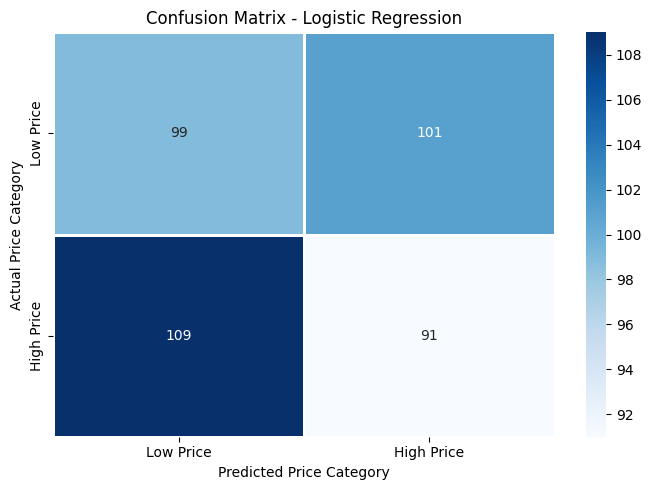

In [52]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low Price', 'High Price'],
    yticklabels=['Low Price', 'High Price'],
    linewidths=1
)

plt.xlabel("Predicted Price Category")
plt.ylabel("Actual Price Category")
plt.title("Confusion Matrix - Logistic Regression")

plt.tight_layout()
plt.show()

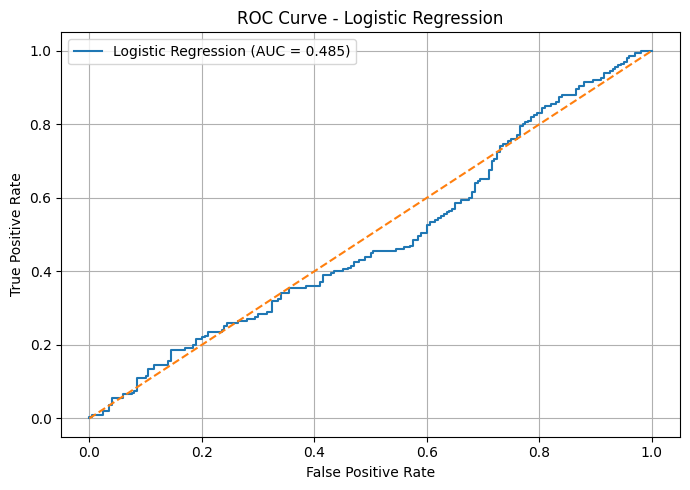

In [53]:
roc_auc_logistic = roc_auc_score( y_test_logistic,y_prob_logistic)

fpr_logistic, tpr_logistic, thresholds_logistic = roc_curve( y_test_logistic, y_prob_logistic)


plt.figure(figsize=(7, 5))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f'Logistic Regression (AUC = {roc_auc_logistic:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
print("\nROC-AUC Score:", roc_auc_logistic)


ROC-AUC Score: 0.485275


KNN

In [55]:


from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [56]:
price_median = df['Price'].median()

df['Price_Category'] = np.where(
    df['Price'] >= price_median,
    1,
    0
)

print("Price Median:", price_median)

print("\nPrice Category Counts:")
print(df['Price_Category'].value_counts())

print("\n0 = Low Price")
print("1 = High Price")

Price Median: 539254.0

Price Category Counts:
Price_Category
0    1000
1    1000
Name: count, dtype: int64

0 = Low Price
1 = High Price


In [57]:
drop_columns = [
    'Price',
    'Price_Category'
]

if 'Id' in df.columns:
    drop_columns.append('Id')

X_knn = df.drop(columns=drop_columns)

y_knn = df['Price_Category']

In [58]:
numeric_features_knn = [
    'Area',
    'Bedrooms',
    'Bathrooms',
    'Floors',
    'YearBuilt'
]

categorical_features_knn = [
    'Location',
    'Condition',
    'Garage'
]


In [59]:
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn,
    y_knn,
    test_size=0.20,
    random_state=42,
    stratify=y_knn
)

print("\nTraining data:", X_train_knn.shape)
print("Testing data :", X_test_knn.shape)



Training data: (1600, 8)
Testing data : (400, 8)


In [60]:
knn_preprocessor = ColumnTransformer(
    transformers=[('num',StandardScaler(),numeric_features_knn),('cat',OneHotEncoder(handle_unknown='ignore'),categorical_features_knn)])

In [61]:
knn_model = Pipeline(
    steps=[('preprocessor',knn_preprocessor),('model',KNeighborsClassifier(n_neighbors=5))])

In [62]:
knn_model.fit(X_train_knn,y_train_knn)

print("\nKNN model trained successfully!")



KNN model trained successfully!


In [63]:
y_pred_knn = knn_model.predict(X_test_knn)

y_prob_knn = knn_model.predict_proba(X_test_knn)[:, 1]


In [64]:
accuracy_knn = accuracy_score(y_test_knn,y_pred_knn)

precision_knn = precision_score(
    y_test_knn,
    y_pred_knn,
    average='weighted'
)

recall_knn = recall_score(y_test_knn,y_pred_knn,average='weighted')

f1_knn = f1_score(y_test_knn,y_pred_knn,average='weighted')


print("\n========== KNN CLASSIFICATION RESULTS ==========")

print("Accuracy :", accuracy_knn)
print("Precision:", precision_knn)
print("Recall   :", recall_knn)
print("F1 Score :", f1_knn)



========== KNN CLASSIFICATION RESULTS ==========
Accuracy : 0.5175
Precision: 0.5175004375109378
Recall   : 0.5175
F1 Score : 0.5174969843561522


In [65]:
print("\nClassification Report:\n")

print(classification_report( y_test_knn,y_pred_knn, target_names=['Low Price','High Price']))


Classification Report:

              precision    recall  f1-score   support

   Low Price       0.52      0.52      0.52       200
  High Price       0.52      0.52      0.52       200

    accuracy                           0.52       400
   macro avg       0.52      0.52      0.52       400
weighted avg       0.52      0.52      0.52       400



In [66]:
cm_knn = confusion_matrix( y_test_knn,y_pred_knn,labels=[0, 1])

print("\nConfusion Matrix:")
print(cm_knn)


Confusion Matrix:
[[103  97]
 [ 96 104]]


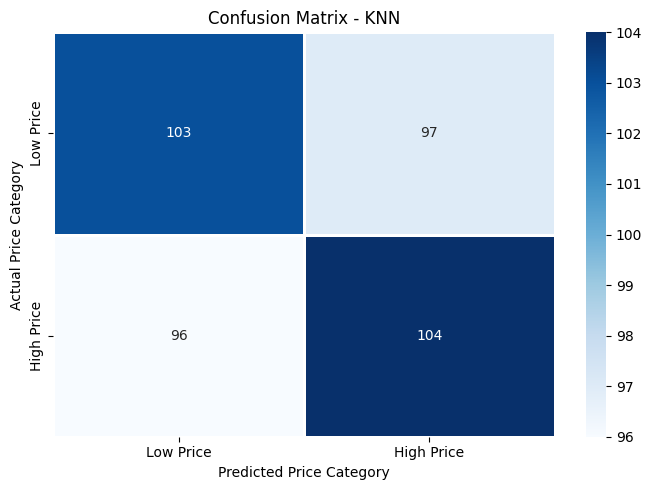

In [67]:
plt.figure(figsize=(7, 5))

sns.heatmap(cm_knn,annot=True,fmt='d',cmap='Blues',xticklabels=['Low Price','High Price'],yticklabels=[ 'Low Price','High Price'],linewidths=1)

plt.xlabel("Predicted Price Category")
plt.ylabel("Actual Price Category")
plt.title("Confusion Matrix - KNN")

plt.tight_layout()
plt.show()

In [68]:
roc_auc_knn = roc_auc_score(y_test_knn,y_prob_knn)

print("\nROC-AUC Score:", roc_auc_knn)




ROC-AUC Score: 0.5174375


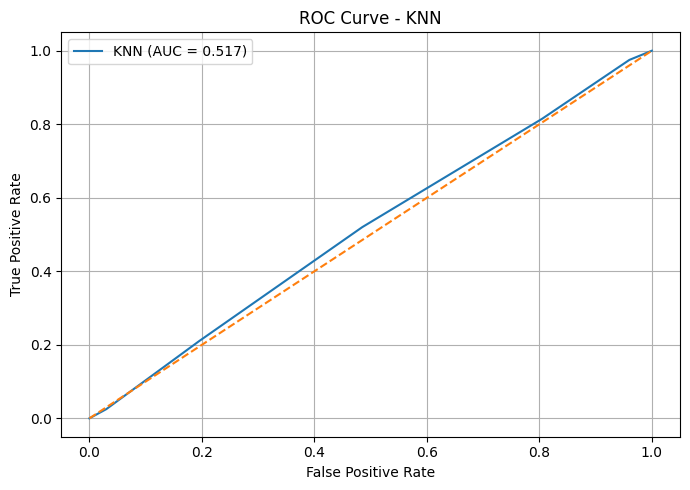

In [69]:
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test_knn,y_prob_knn)

plt.figure(figsize=(7, 5))

plt.plot( fpr_knn,tpr_knn,label=f'KNN (AUC = {roc_auc_knn:.3f})')

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Decision Tree Classification

In [70]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)


In [71]:
price_median = df['Price'].median()

df['Price_Category'] = np.where(
    df['Price'] >= price_median,
    1,
    0
)

print("Price Median:", price_median)

print("\nPrice Category Counts:")
print(df['Price_Category'].value_counts())

print("\n0 = Low Price")
print("1 = High Price")


Price Median: 539254.0

Price Category Counts:
Price_Category
0    1000
1    1000
Name: count, dtype: int64

0 = Low Price
1 = High Price


In [72]:
drop_columns = [
    'Price',
    'Price_Category'
]

# Remove ID column if it exists
if 'Id' in df.columns:
    drop_columns.append('Id')

X_dt = df.drop(columns=drop_columns)

y_dt = df['Price_Category']


In [73]:
numeric_features_dt = [
    'Area',
    'Bedrooms',
    'Bathrooms',
    'Floors',
    'YearBuilt'
]

categorical_features_dt = [
    'Location',
    'Condition',
    'Garage'
]

In [74]:
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split( X_dt,y_dt,test_size=0.20,random_state=42,stratify=y_dt)

print("\nTraining data:", X_train_dt.shape)
print("Testing data :", X_test_dt.shape)



Training data: (1600, 8)
Testing data : (400, 8)


In [75]:
dt_preprocessor = ColumnTransformer(
    transformers=[ ('num','passthrough',numeric_features_dt),( 'cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_dt )])


In [76]:

dt_model = Pipeline(
    steps=[( 'preprocessor',dt_preprocessor ),('model',DecisionTreeClassifier(criterion='gini',max_depth=5, random_state=42))])

In [77]:
dt_model.fit( X_train_dt, y_train_dt)

print("\nDecision Tree model trained successfully!")


Decision Tree model trained successfully!


In [78]:
y_pred_dt = dt_model.predict( X_test_dt)

y_prob_dt = dt_model.predict_proba(X_test_dt)[:, 1]

In [79]:
accuracy_dt = accuracy_score(y_test_dt,y_pred_dt)

precision_dt = precision_score( y_test_dt, y_pred_dt, average='weighted')

recall_dt = recall_score(y_test_dt,y_pred_dt,average='weighted')

f1_dt = f1_score( y_test_dt, y_pred_dt, average='weighted')


print("\n========== DECISION TREE RESULTS ==========")

print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)


========== DECISION TREE RESULTS ==========
Accuracy : 0.49
Precision: 0.4898989898989899
Recall   : 0.49
F1 Score : 0.48872180451127817


In [80]:
print("\nClassification Report:\n")

print( classification_report( y_test_dt,y_pred_dt, target_names=[ 'Low Price','High Price'] ))



Classification Report:

              precision    recall  f1-score   support

   Low Price       0.49      0.44      0.46       200
  High Price       0.49      0.54      0.51       200

    accuracy                           0.49       400
   macro avg       0.49      0.49      0.49       400
weighted avg       0.49      0.49      0.49       400



In [81]:
cm_dt = confusion_matrix( y_test_dt, y_pred_dt, labels=[0, 1])

print("\nConfusion Matrix:")
print(cm_dt)



Confusion Matrix:
[[ 88 112]
 [ 92 108]]


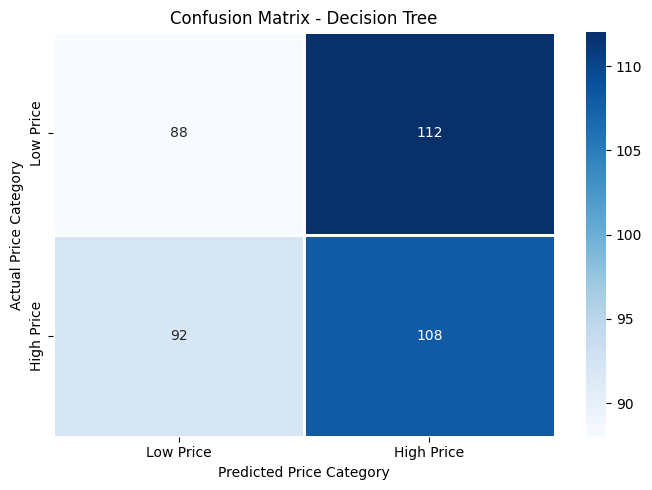

In [82]:
plt.figure(figsize=(7, 5))

sns.heatmap(cm_dt,annot=True,fmt='d',cmap='Blues',xticklabels=['Low Price','High Price'],yticklabels=['Low Price','High Price'],linewidths=1)

plt.xlabel("Predicted Price Category")
plt.ylabel("Actual Price Category")
plt.title("Confusion Matrix - Decision Tree")

plt.tight_layout()
plt.show()

In [83]:
roc_auc_dt = roc_auc_score(y_test_dt,y_prob_dt)

print("\nROC-AUC Score:", roc_auc_dt)


ROC-AUC Score: 0.5001125


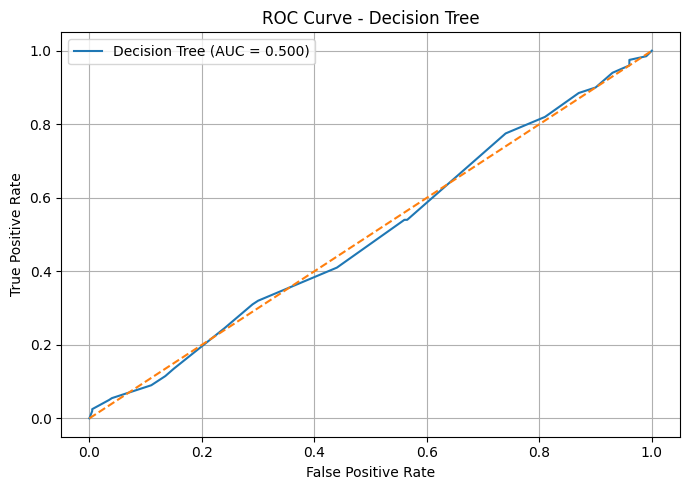

In [84]:
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test_dt, y_prob_dt)

plt.figure(figsize=(7, 5))

plt.plot(fpr_dt,tpr_dt,label=f'Decision Tree (AUC = {roc_auc_dt:.3f})')

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Decision Tree Regression

In [85]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

In [86]:
X = df.drop(columns=['Price'])
y = df['Price']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\nFirst 5 target values:")
print(y.head())

X shape: (2000, 10)
y shape: (2000,)

X columns:
['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price_Category']

First 5 target values:
0    149919
1    424998
2    266746
3    244020
4    636056
Name: Price, dtype: int64


In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1600, 10)
X_test : (400, 10)
y_train: (1600,)
y_test : (400,)


In [88]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("Standard Scaler and One Hot Encoder created successfully")

Standard Scaler and One Hot Encoder created successfully


In [89]:
numeric_features = [
    'Area',
    'Bedrooms',
    'Bathrooms',
    'Floors',
    'YearBuilt'
]

categorical_features = [
    'Location',
    'Condition',
    'Garage'
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']

Categorical features:
['Location', 'Condition', 'Garage']


In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1600, 10)
X_test : (400, 10)
y_train: (1600,)
y_test : (400,)


In [91]:
dt_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(
            max_depth=5,
            random_state=42
        ))
    ]
)

print("Decision Tree Regression model created successfully")

Decision Tree Regression model created successfully


In [92]:
dt_model.fit(X_train, y_train)

print("Decision Tree Regression model trained successfully")

Decision Tree Regression model trained successfully


In [93]:
y_pred_dt = dt_model.predict(X_test)

print("Predictions created successfully")
print("First 10 predictions:")
print(y_pred_dt[:10])

Predictions created successfully
First 10 predictions:
[534541.58024691 349074.9375     506292.4368231  613141.48101266
 676322.54666667 613141.48101266 497298.64666667 497298.64666667
 572328.12871287 676322.54666667]


In [94]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("=" * 60)
print("DECISION TREE REGRESSION RESULTS")
print("=" * 60)

print("\nFirst 10 Actual Prices:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Predicted Prices:")
print(y_pred_dt[:10])

print("\nMAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)

DECISION TREE REGRESSION RESULTS

First 10 Actual Prices:
[514764 694256  66375 650243 223285 468127 513002 911525 723265 339416]

First 10 Predicted Prices:
[534541.58024691 349074.9375     506292.4368231  613141.48101266
 676322.54666667 613141.48101266 497298.64666667 497298.64666667
 572328.12871287 676322.54666667]

MAE : 249963.10383798045
MSE : 85127094295.12189
RMSE: 291765.4782442945
R²  : -0.09419506584662907


Support Vector Classification

In [95]:
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [96]:
price_median = df['Price'].median()

df['Price_Category'] = np.where(
    df['Price'] >= price_median,
    1,
    0
)

print("Price Median:", price_median)

print("\nPrice Category Counts:")
print(df['Price_Category'].value_counts())

print("\n0 = Low Price")
print("1 = High Price")


Price Median: 539254.0

Price Category Counts:
Price_Category
0    1000
1    1000
Name: count, dtype: int64

0 = Low Price
1 = High Price


In [97]:
drop_columns_svc = [
    'Price',
    'Price_Category'
]

if 'Id' in df.columns:
    drop_columns_svc.append('Id')

X_svc = df.drop(columns=drop_columns_svc)

y_svc = df['Price_Category']

In [98]:
numeric_features_svc = [
    'Area',
    'Bedrooms',
    'Bathrooms',
    'Floors',
    'YearBuilt'
]

categorical_features_svc = [
    'Location',
    'Condition',
    'Garage'
]


In [99]:
X_train_svc, X_test_svc, y_train_svc, y_test_svc = train_test_split(
    X_svc,
    y_svc,
    test_size=0.20,
    random_state=42,
    stratify=y_svc
)

print("\nTraining data:", X_train_svc.shape)
print("Testing data :", X_test_svc.shape)




Training data: (1600, 8)
Testing data : (400, 8)


In [100]:
svc_preprocessor = ColumnTransformer(
    transformers=[('num',StandardScaler(),numeric_features_svc),('cat',OneHotEncoder(handle_unknown='ignore'),categorical_features_svc) ])

In [101]:
svc_model = Pipeline( steps=[('preprocessor',svc_preprocessor),( 'model', SVC(kernel='rbf',C=1.0,gamma='scale',probability=True,random_state=42) )])


In [102]:
svc_model.fit(X_train_svc,y_train_svc)

print("\nSVC model trained successfully!")


SVC model trained successfully!


In [103]:
y_pred_svc = svc_model.predict(X_test_svc)

y_prob_svc = svc_model.predict_proba(X_test_svc)[:, 1]

In [104]:
accuracy_svc = accuracy_score(y_test_svc, y_pred_svc)

precision_svc = precision_score(y_test_svc,y_pred_svc,average='weighted')

recall_svc = recall_score( y_test_svc, y_pred_svc, average='weighted')

f1_svc = f1_score(y_test_svc,y_pred_svc,average='weighted')


print("\n========== SVC CLASSIFICATION RESULTS ==========")

print("Accuracy :", accuracy_svc)
print("Precision:", precision_svc)
print("Recall   :", recall_svc)
print("F1 Score :", f1_svc)



========== SVC CLASSIFICATION RESULTS ==========
Accuracy : 0.5225
Precision: 0.5225682690137667
Recall   : 0.5225
F1 Score : 0.5221386173293554


In [105]:
print("\nClassification Report:\n")

print(classification_report( y_test_svc,y_pred_svc,target_names=[ 'Low Price', 'High Price'] ))


Classification Report:

              precision    recall  f1-score   support

   Low Price       0.52      0.49      0.51       200
  High Price       0.52      0.55      0.54       200

    accuracy                           0.52       400
   macro avg       0.52      0.52      0.52       400
weighted avg       0.52      0.52      0.52       400



In [106]:
cm_svc = confusion_matrix(y_test_svc,y_pred_svc,labels=[0, 1])

print("\nConfusion Matrix:")
print(cm_svc)



Confusion Matrix:
[[ 99 101]
 [ 90 110]]


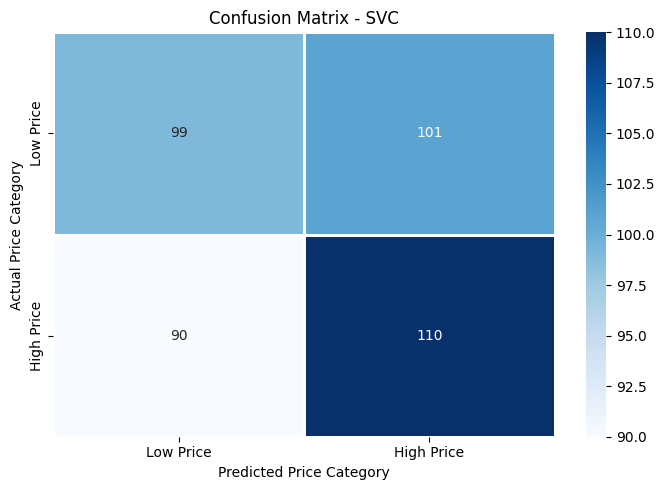

In [107]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_svc,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Low Price',
        'High Price'
    ],
    yticklabels=[
        'Low Price',
        'High Price'
    ],
    linewidths=1
)

plt.xlabel("Predicted Price Category")
plt.ylabel("Actual Price Category")
plt.title("Confusion Matrix - SVC")

plt.tight_layout()
plt.show()


In [108]:
roc_auc_svc = roc_auc_score(y_test_svc,y_prob_svc)

print("\nROC-AUC Score:", roc_auc_svc)


ROC-AUC Score: 0.48935000000000006


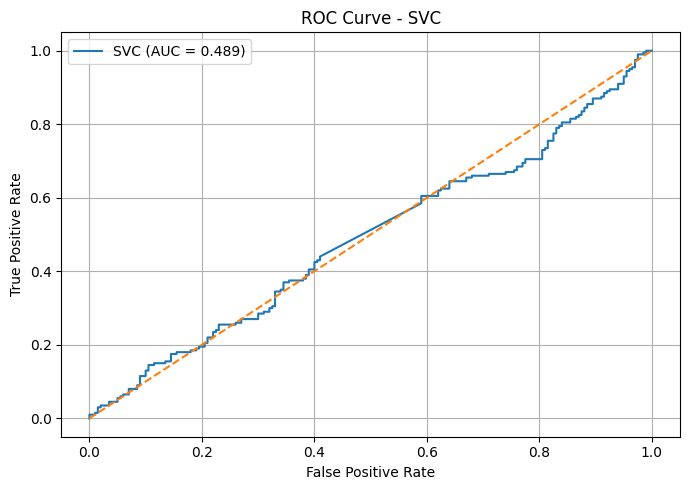

In [109]:
fpr_svc, tpr_svc, thresholds_svc = roc_curve(y_test_svc,y_prob_svc)

plt.figure(figsize=(7, 5))

plt.plot(fpr_svc,tpr_svc,label=f'SVC (AUC = {roc_auc_svc:.3f})')

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVC")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Support Vector Regression

In [110]:

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


In [111]:
drop_columns_svr = ['Price']

if 'Id' in df.columns:
    drop_columns_svr.append('Id')

X_svr = df.drop(columns=drop_columns_svr)
y_svr = df['Price']


In [112]:
numeric_features_svr = [
    'Area',
    'Bedrooms',
    'Bathrooms',
    'Floors',
    'YearBuilt'
]

categorical_features_svr = [
    'Location',
    'Condition',
    'Garage'
]

In [113]:
X_train_svr, X_test_svr, y_train_svr, y_test_svr = train_test_split(X_svr,y_svr,test_size=0.20,random_state=42)


In [114]:
svr_preprocessor = ColumnTransformer(
    transformers=[('num',StandardScaler(),numeric_features_svr),( 'cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_svr) ])


In [115]:
svr_model = Pipeline(steps=[('preprocessor',svr_preprocessor),('model',SVR(kernel='rbf',C=100,epsilon=0.1,gamma='scale') )])

In [116]:
svr_model.fit(X_train_svr, y_train_svr)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [117]:
y_pred_svr = svr_model.predict(X_test_svr)

In [118]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse_svr = mean_squared_error(
    y_test_svr,
    y_pred_svr
)

mae_svr = mean_absolute_error(
    y_test_svr,
    y_pred_svr
)

r2_svr = r2_score(
    y_test_svr,
    y_pred_svr
)

print("SVR Regression Results")
print("----------------------")
print("Mean Squared Error :", mse_svr)
print("Mean Absolute Error:", mae_svr)
print("R² Score           :", r2_svr)

SVR Regression Results
----------------------
Mean Squared Error : 77908143776.13426
Mean Absolute Error: 242692.04757788894
R² Score           : -0.0014051015717664317


Bagging Classification

In [119]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [120]:
price_median = df['Price'].median()

df['Price_Category'] = np.where(
    df['Price'] >= price_median,
    1,
    0
)

print("Price Median:", price_median)

print("\nPrice Category Counts:")
print(df['Price_Category'].value_counts())

print("\n0 = Low Price")
print("1 = High Price")


Price Median: 539254.0

Price Category Counts:
Price_Category
0    1000
1    1000
Name: count, dtype: int64

0 = Low Price
1 = High Price


In [121]:
drop_columns_bagging = ['Price','Price_Category']


if 'Id' in df.columns:
    drop_columns_bagging.append('Id')

X_bagging = df.drop(columns=drop_columns_bagging)

y_bagging = df['Price_Category']

In [122]:
numeric_features_bagging = [
    'Area',
    'Bedrooms',
    'Bathrooms',
    'Floors',
    'YearBuilt'
]


categorical_features_bagging = [
    'Location',
    'Condition',
    'Garage'
]

In [123]:
X_train_bagging, X_test_bagging, y_train_bagging, y_test_bagging = train_test_split(
    X_bagging,
    y_bagging,
    test_size=0.20,
    random_state=42,
    stratify=y_bagging
)

print("\nTraining data:", X_train_bagging.shape)
print("Testing data :", X_test_bagging.shape)


Training data: (1600, 8)
Testing data : (400, 8)


In [124]:
bagging_preprocessor = ColumnTransformer(transformers=[('num','passthrough',numeric_features_bagging),('cat',OneHotEncoder(handle_unknown='ignore'),categorical_features_bagging)])

In [125]:
bagging_base_model = DecisionTreeClassifier( max_depth=5,random_state=42)



In [126]:
bagging_classifier = BaggingClassifier(
    estimator=bagging_base_model,
    n_estimators=100,
    max_samples=0.8,
    max_features=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

In [127]:
bagging_model = Pipeline(steps=[('preprocessor', bagging_preprocessor),('model',bagging_classifier ) ])

In [128]:
bagging_model.fit( X_train_bagging,y_train_bagging)

print("\nBagging Classification model trained successfully!")



Bagging Classification model trained successfully!


In [129]:
y_pred_bagging = bagging_model.predict(X_test_bagging)

y_prob_bagging = bagging_model.predict_proba( X_test_bagging)[:, 1]

In [130]:
accuracy_bagging = accuracy_score(y_test_bagging,y_pred_bagging)

precision_bagging = precision_score(y_test_bagging,y_pred_bagging,average='weighted')

recall_bagging = recall_score(y_test_bagging,y_pred_bagging,average='weighted')

f1_bagging = f1_score( y_test_bagging, y_pred_bagging, average='weighted')


print("\n========== BAGGING CLASSIFICATION RESULTS ==========")

print("Accuracy :", accuracy_bagging)
print("Precision:", precision_bagging)
print("Recall   :", recall_bagging)
print("F1 Score :", f1_bagging)



========== BAGGING CLASSIFICATION RESULTS ==========
Accuracy : 0.505
Precision: 0.5050505050505051
Recall   : 0.505
F1 Score : 0.5037593984962406


In [131]:
print("\nClassification Report:\n")

print(classification_report(y_test_bagging,y_pred_bagging,target_names=['Low Price','High Price']))


Classification Report:

              precision    recall  f1-score   support

   Low Price       0.50      0.56      0.53       200
  High Price       0.51      0.46      0.48       200

    accuracy                           0.51       400
   macro avg       0.51      0.51      0.50       400
weighted avg       0.51      0.51      0.50       400



In [132]:
cm_bagging = confusion_matrix(y_test_bagging,y_pred_bagging,labels=[0, 1])

print("\nConfusion Matrix:")
print(cm_bagging)


Confusion Matrix:
[[111  89]
 [109  91]]


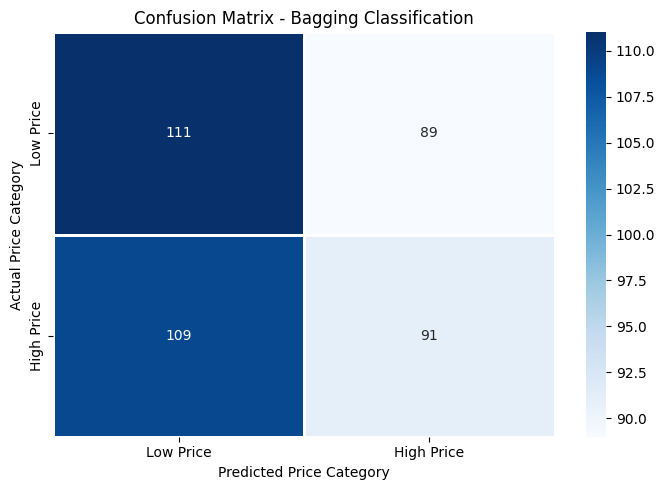

In [133]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_bagging,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Low Price',
        'High Price'
    ],
    yticklabels=[
        'Low Price',
        'High Price'
    ],
    linewidths=1
)

plt.xlabel("Predicted Price Category")
plt.ylabel("Actual Price Category")
plt.title("Confusion Matrix - Bagging Classification")

plt.tight_layout()
plt.show()


In [134]:
roc_auc_bagging = roc_auc_score(y_test_bagging,y_prob_bagging)

print("\nROC-AUC Score:", roc_auc_bagging)


ROC-AUC Score: 0.5143875


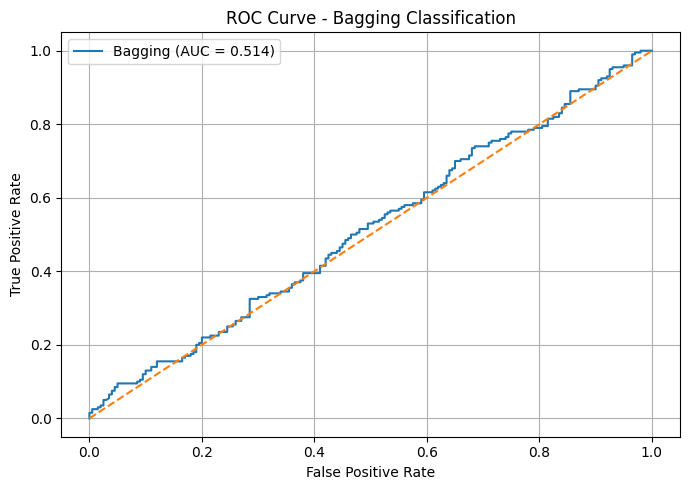

In [135]:

fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(y_test_bagging,y_prob_bagging)

plt.figure(figsize=(7, 5))

plt.plot(fpr_bagging,tpr_bagging,label=f'Bagging (AUC = {roc_auc_bagging:.3f})')

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Bagging Classification")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Gradient Boosting

In [136]:
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)


In [137]:
price_median = df['Price'].median()

df['Price_Category'] = np.where(
    df['Price'] >= price_median,
    1,
    0
)

print("Price Median:", price_median)

print("\nPrice Category Counts:")
print(df['Price_Category'].value_counts())

print("\n0 = Low Price")
print("1 = High Price")


Price Median: 539254.0

Price Category Counts:
Price_Category
0    1000
1    1000
Name: count, dtype: int64

0 = Low Price
1 = High Price


In [138]:
drop_columns_gb = [
    'Price',
    'Price_Category'
]


if 'Id' in df.columns:
    drop_columns_gb.append('Id')

X_gb = df.drop(columns=drop_columns_gb)

y_gb = df['Price_Category']

In [139]:
numeric_features_gb = [
    'Area',
    'Bedrooms',
    'Bathrooms',
    'Floors',
    'YearBuilt'
]



categorical_features_gb = [
    'Location',
    'Condition',
    'Garage'
]


In [140]:
X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(
    X_gb,
    y_gb,
    test_size=0.20,
    random_state=42,
    stratify=y_gb
)

print("\nTraining data:", X_train_gb.shape)
print("Testing data :", X_test_gb.shape)


Training data: (1600, 8)
Testing data : (400, 8)


In [141]:
gb_preprocessor = ColumnTransformer(
    transformers=[('num','passthrough',numeric_features_gb),('cat',OneHotEncoder(handle_unknown='ignore'),categorical_features_gb )])


In [142]:
gb_model = Pipeline(steps=[ ( 'preprocessor', gb_preprocessor),('model',GradientBoostingClassifier( n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))])


In [143]:
gb_model.fit(X_train_gb,y_train_gb)

print("\nGradient Boosting model trained successfully!")


Gradient Boosting model trained successfully!


In [144]:
y_pred_gb = gb_model.predict( X_test_gb)

y_prob_gb = gb_model.predict_proba( X_test_gb)[:, 1]

In [145]:
accuracy_gb = accuracy_score( y_test_gb, y_pred_gb)

precision_gb = precision_score( y_test_gb, y_pred_gb, average='weighted')

recall_gb = recall_score(y_test_gb,y_pred_gb,average='weighted')

f1_gb = f1_score(
    y_test_gb,
    y_pred_gb,
    average='weighted'
)


print("\n========== GRADIENT BOOSTING RESULTS ==========")

print("Accuracy :", accuracy_gb)
print("Precision:", precision_gb)
print("Recall   :", recall_gb)
print("F1 Score :", f1_gb)


========== GRADIENT BOOSTING RESULTS ==========
Accuracy : 0.5325
Precision: 0.5325073141456828
Recall   : 0.5325
F1 Score : 0.5324737016457175


In [146]:
print("\nClassification Report:\n")

print(classification_report(y_test_gb,y_pred_gb,target_names=['Low Price','High Price' ] ))



Classification Report:

              precision    recall  f1-score   support

   Low Price       0.53      0.53      0.53       200
  High Price       0.53      0.54      0.54       200

    accuracy                           0.53       400
   macro avg       0.53      0.53      0.53       400
weighted avg       0.53      0.53      0.53       400



In [147]:
cm_gb = confusion_matrix(y_test_gb,y_pred_gb,labels=[0, 1])

print("\nConfusion Matrix:")
print(cm_gb)


Confusion Matrix:
[[105  95]
 [ 92 108]]


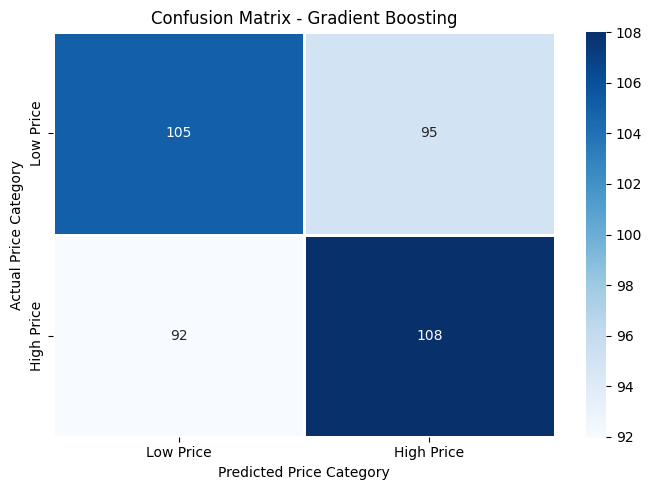

In [148]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Low Price',
        'High Price'
    ],
    yticklabels=[
        'Low Price',
        'High Price'
    ],
    linewidths=1
)

plt.xlabel("Predicted Price Category")
plt.ylabel("Actual Price Category")
plt.title("Confusion Matrix - Gradient Boosting")

plt.tight_layout()
plt.show()


In [149]:
roc_auc_gb = roc_auc_score(y_test_gb,y_prob_gb)

print("\nROC-AUC Score:", roc_auc_gb)


ROC-AUC Score: 0.54465


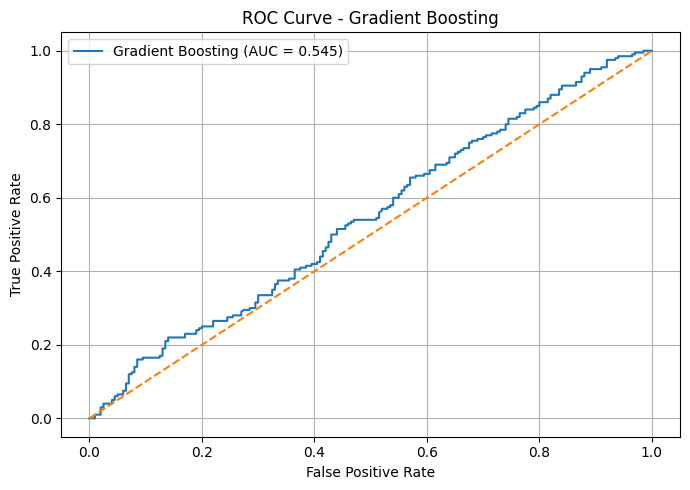

In [150]:
fpr_gb, tpr_gb, thresholds_gb = roc_curve( y_test_gb, y_prob_gb)

plt.figure(figsize=(7, 5))

plt.plot(fpr_gb,tpr_gb,label=f'Gradient Boosting (AUC = {roc_auc_gb:.3f})')

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Random Forest Classification

In [151]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [152]:
price_median = df['Price'].median()

df['Price_Category'] = np.where(
    df['Price'] >= price_median,
    1,
    0
)


In [153]:
drop_columns_rf = ['Price', 'Price_Category']

if 'Id' in df.columns:
    drop_columns_rf.append('Id')

X_rf = df.drop(columns=drop_columns_rf)
y_rf = df['Price_Category']

In [154]:
numeric_features_rf = [
    'Area',
    'Bedrooms',
    'Bathrooms',
    'Floors',
    'YearBuilt'
]

categorical_features_rf = [
    'Location',
    'Condition',
    'Garage'
]


In [155]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.20,
    random_state=42,
    stratify=y_rf
)

In [156]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features_rf),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_rf)
    ]
)

In [157]:
rf_model = Pipeline(
    steps=[ ('preprocessor', rf_preprocessor),('model', RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42,n_jobs=-1 )) ])

In [158]:
rf_model.fit(X_train_rf,y_train_rf)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [159]:
y_pred_rf = rf_model.predict(X_test_rf)

y_prob_rf = rf_model.predict_proba(X_test_rf)[:, 1]


In [160]:
accuracy_rf = accuracy_score( y_test_rf,y_pred_rf)

precision_rf = precision_score(y_test_rf, y_pred_rf,average='weighted')

recall_rf = recall_score( y_test_rf, y_pred_rf,average='weighted')

f1_rf = f1_score( y_test_rf, y_pred_rf, average='weighted')

print("Random Forest Classifier")
print("------------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Random Forest Classifier
------------------------
Accuracy : 0.5075
Precision: 0.5075016878797729
Recall   : 0.5075
F1 Score : 0.5074722953166116


In [161]:
print("\nClassification Report:\n")

print(classification_report( y_test_rf, y_pred_rf, target_names=[ 'Low Price', 'High Price'] ))


Classification Report:

              precision    recall  f1-score   support

   Low Price       0.51      0.50      0.50       200
  High Price       0.51      0.52      0.51       200

    accuracy                           0.51       400
   macro avg       0.51      0.51      0.51       400
weighted avg       0.51      0.51      0.51       400



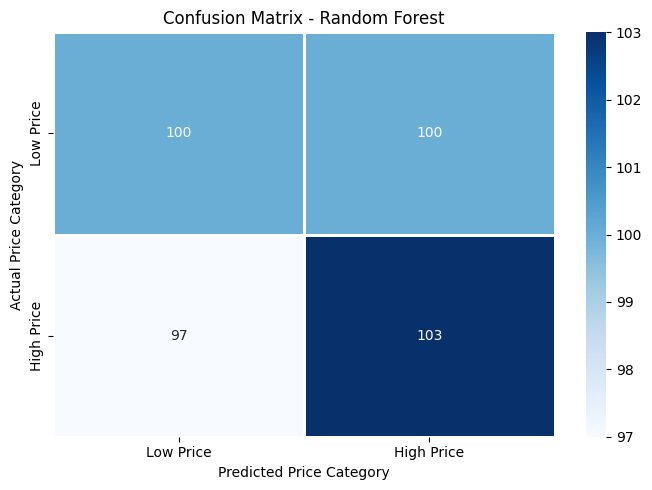

In [162]:
cm_rf = confusion_matrix(y_test_rf,y_pred_rf,labels=[0, 1])

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Low Price',
        'High Price'
    ],
    yticklabels=[
        'Low Price',
        'High Price'
    ],
    linewidths=1
)

plt.xlabel("Predicted Price Category")
plt.ylabel("Actual Price Category")
plt.title("Confusion Matrix - Random Forest")

plt.tight_layout()
plt.show()


In [163]:
roc_auc_rf = roc_auc_score(y_test_rf, y_prob_rf)

print("ROC-AUC Score:", roc_auc_rf)

ROC-AUC Score: 0.5063500000000001


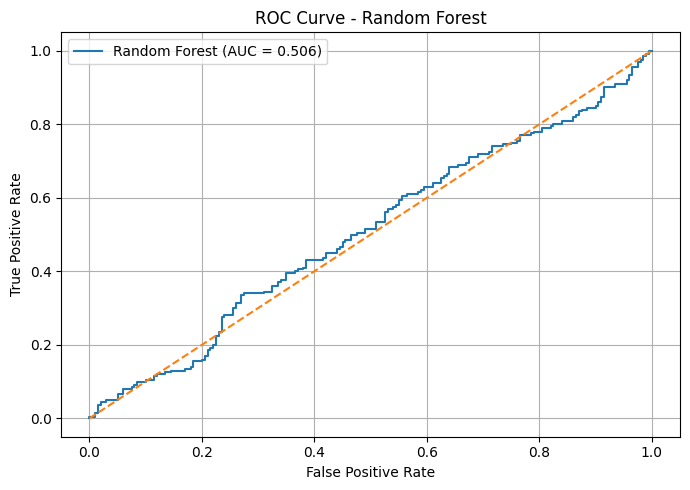

In [164]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve( y_test_rf, y_prob_rf)

plt.figure(figsize=(7, 5))

plt.plot( fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Random Forest Regression

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



In [166]:
X = df.drop(columns=['Price'])
y = df['Price']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\nFirst 5 target values:")
print(y.head())

X shape: (2000, 10)
y shape: (2000,)

X columns:
['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price_Category']

First 5 target values:
0    149919
1    424998
2    266746
3    244020
4    636056
Name: Price, dtype: int64


In [167]:
numeric_features = [
    'Area',
    'Bedrooms',
    'Bathrooms',
    'Floors',
    'YearBuilt'
]

categorical_features = [
    'Location',
    'Condition',
    'Garage'
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']

Categorical features:
['Location', 'Condition', 'Garage']


In [168]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1600, 10)
X_test : (400, 10)
y_train: (1600,)
y_test : (400,)


In [169]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("Standard Scaler and One Hot Encoder created successfully")

Standard Scaler and One Hot Encoder created successfully


In [170]:
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

print("Random Forest Regression model created successfully")

Random Forest Regression model created successfully


In [171]:
rf_model.fit(X_train, y_train)

print("Random Forest Regression model trained successfully")

Random Forest Regression model trained successfully


In [172]:
y_pred_rf = rf_model.predict(X_test)

print("Predictions created successfully")

print("\nFirst 10 predictions:")
print(y_pred_rf[:10])

Predictions created successfully

First 10 predictions:
[639335.32 464546.32 545779.72 473687.87 553388.56 562218.63 513167.53
 600781.69 621231.85 628282.27]


In [173]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=" * 60)
print("RANDOM FOREST REGRESSION RESULTS")
print("=" * 60)

print("\nFirst 10 Actual Prices:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Predicted Prices:")
print(y_pred_rf[:10])

print("\nMAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

RANDOM FOREST REGRESSION RESULTS

First 10 Actual Prices:
[514764 694256  66375 650243 223285 468127 513002 911525 723265 339416]

First 10 Predicted Prices:
[639335.32 464546.32 545779.72 473687.87 553388.56 562218.63 513167.53
 600781.69 621231.85 628282.27]

MAE : 254587.840175
MSE : 86571527999.46388
RMSE: 294230.39951620204
R²  : -0.1127613313267386
